# Chest Press push-phase segment analysis

This notebook detects each concentric pushing phase, normalizes it to 0–100%, divides it into **early**, **middle**, and **late** thirds, and compares the first 30% with the last 30% of repetitions in the same set.

The result is a **candidate weak region**, not an anatomical diagnosis. Wrist acceleration is not bar position, force, or muscle activation.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from push_phase_analysis import (
    BENCH, SEGMENTS, build_segment_table, build_summary_table,
    detect_push_phases, load_project_data, load_signal,
)

TABLES_DIR = Path("../reports/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
recordings, samples = load_project_data()
bench = recordings.loc[recordings.activity_name == BENCH]
print(f"Chest Press recordings: {len(bench)}, subjects: {bench.subject_id.nunique()}")

Chest Press recordings: 31, subjects: 21


## Method

The dominant accelerometer axis is low-pass filtered, and autocorrelation plus peak detection finds trough-to-peak pushing phases. Each phase is interpolated to 101 points and split into early (0–33%), middle (33–67%), and late (67–100%) time regions.

The primary feature is `progress_rate_per_s`: how quickly the smoothed signal traverses its total trough-to-peak range in that region. Raw dynamic acceleration features are retained as supporting measurements. These are IMU proxies—not physical bar speed or force.

In [2]:
segment_df, profiles_df = build_segment_table(recordings, samples)
summary_df = build_summary_table(segment_df)
segment_df.to_csv(TABLES_DIR / "push_phase_segment_features.csv", index=False)
summary_df.to_csv(TABLES_DIR / "push_phase_early_vs_late_summary.csv", index=False)

n_pushes = segment_df[["record_uid", "rep_index"]].drop_duplicates().shape[0]
print(f"Detected {n_pushes} pushes from {segment_df.record_uid.nunique()} recordings")
detected_counts = segment_df.groupby("record_uid").rep_index.max().rename("detected_reps")
coverage = bench[["record_uid", "activity_reps"]].merge(detected_counts, on="record_uid", how="left").fillna({"detected_reps": 0})
coverage["absolute_error"] = (coverage.detected_reps - coverage.activity_reps).abs()
print(f"Detection-count MAE: {coverage.absolute_error.mean():.2f} reps; recordings with no valid push: {(coverage.detected_reps == 0).sum()}")
display(coverage.loc[coverage.detected_reps == 0])
display(segment_df.head(9))

Detected 432 pushes from 30 recordings
Detection-count MAE: 2.68 reps; recordings with no valid push: 1


,record_uid,activity_reps,detected_reps,absolute_error
2,singleonly_subject007_Chest_Press_(rack)_recor...,20,0.0,20.0


,record_uid,subject_id,axis,rep_index,n_reps_detected,phase_duration_s,segment,rise_fraction,progress_rate_per_s,mean_abs_dynamic_g,rms_dynamic_g,peak_dynamic_g
0,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,1,20,1.10,early,0.316299,0.862633,0.084814,0.104090,0.233346
1,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,1,20,1.10,middle,0.336915,0.918859,0.182418,0.197429,0.302373
2,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,1,20,1.10,late,0.346786,0.945780,0.331476,0.340680,0.463236
3,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,2,20,1.02,early,0.334421,0.983591,0.127883,0.149466,0.331418
4,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,2,20,1.02,middle,0.414879,1.220233,0.333614,0.361603,0.627037
5,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,2,20,1.02,late,0.250700,0.737353,0.523460,0.527528,0.637064
6,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,3,20,1.20,early,0.386431,0.966077,0.130369,0.177859,0.456305
7,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,3,20,1.20,middle,0.354479,0.886197,0.316468,0.336207,0.452942
8,singleonly_subject001_Chest_Press_(rack)_recor...,3,accel_x_g,3,20,1.20,late,0.259090,0.647726,0.485461,0.490033,0.584193


## Within-set weak-region comparison

For each recording, medians from the first and last 30% of detected pushes are compared. A candidate weak region is flagged only when the smallest late/early progress-rate ratio is below 0.90—at least a 10% deterioration. This avoids forcing every set to have a weak region. At least six detected pushes are also required. The 10% threshold is exploratory and still needs external validation.

In [3]:
candidates = summary_df.loc[summary_df.candidate_weak_region].copy()
print("Candidate weak-region counts across eligible sets:")
display(candidates.segment.value_counts().rename_axis("segment").to_frame("sets"))
print("Late/early progress-rate ratio by region (lower means more deterioration):")
display(summary_df.groupby("segment").late_to_early_rate_ratio.describe().round(3))

Candidate weak-region counts across eligible sets:


,sets
segment,
late,9
middle,6
early,4


Late/early progress-rate ratio by region (lower means more deterioration):


,count,mean,std,min,25%,50%,75%,max
segment,,,,,,,,
early,30.0,1.099,0.515,0.313,0.908,1.004,1.136,3.225
late,30.0,1.695,1.804,0.119,0.832,1.039,1.850,9.139
middle,25.0,1.980,4.346,0.000,0.845,1.012,1.357,22.556


## Visual validation on a real set

The left plot verifies detected thirds on the signal. The right plot compares median normalized pushes from the beginning and end of that set. A numerical flag should not be trusted when phase detection is visibly wrong.

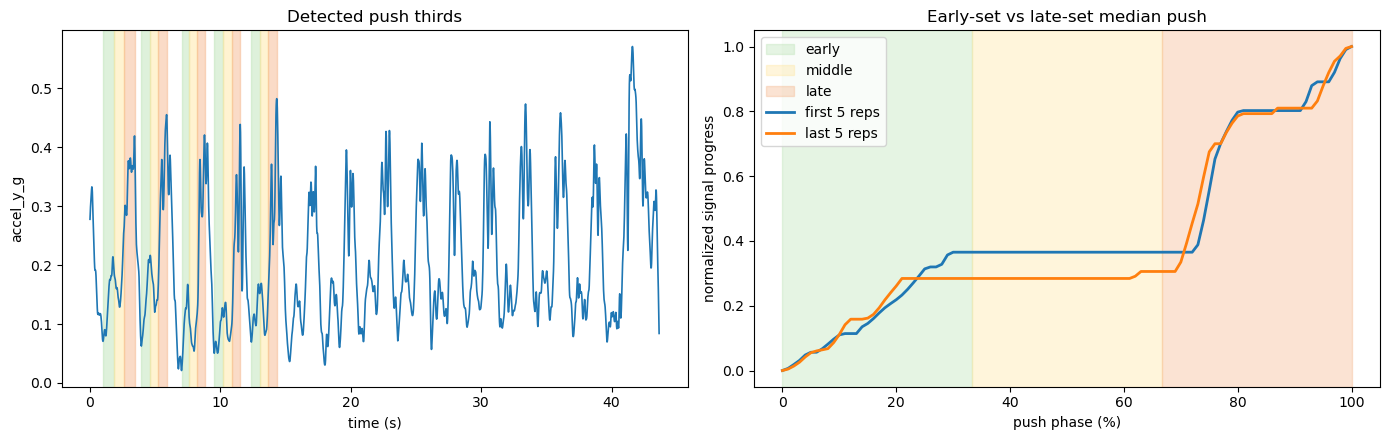

In [4]:
example_uid = candidates.sort_values("late_to_early_rate_ratio").iloc[0].record_uid
signal = load_signal(samples, example_uid)
axis, raw, filtered, phases = detect_push_phases(signal)
time_s = (signal.time_s - signal.time_s.iloc[0]).to_numpy()
colors = {"early": "#b7e1b0", "middle": "#ffe599", "late": "#f4b183"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(time_s, filtered, lw=1.2)
for start, end in phases[:5]:
    for name, (left, right) in SEGMENTS.items():
        x0 = time_s[start] + left * (time_s[end] - time_s[start])
        x1 = time_s[start] + right * (time_s[end] - time_s[start])
        axes[0].axvspan(x0, x1, color=colors[name], alpha=0.45)
axes[0].set(title="Detected push thirds", xlabel="time (s)", ylabel=axis)

profiles = profiles_df.loc[profiles_df.record_uid == example_uid].sort_values("rep_index")
count = max(2, int(np.ceil(0.30 * len(profiles))))
early_profile = np.median(np.stack(profiles.head(count).profile), axis=0)
late_profile = np.median(np.stack(profiles.tail(count).profile), axis=0)
phase_pct = np.linspace(0, 100, 101)
for name, (left, right) in SEGMENTS.items():
    axes[1].axvspan(100*left, 100*right, color=colors[name], alpha=0.35, label=name)
axes[1].plot(phase_pct, early_profile, label=f"first {count} reps", lw=2)
axes[1].plot(phase_pct, late_profile, label=f"last {count} reps", lw=2)
axes[1].set(title="Early-set vs late-set median push", xlabel="push phase (%)", ylabel="normalized signal progress")
axes[1].legend()
plt.tight_layout()
plt.show()

## Interpretation

This answers: **which part of this person's push changed most from the beginning to the end of this set?** It does not identify a weak muscle. The next validation step is synchronized video or a bar-position/velocity reference, with true bottom, sticking, and lockout regions labelled independently.